In [1]:
import commot as ct
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df_ligrec=ct.pp.ligand_receptor_database(species='mouse', signaling_type='Secreted Signaling', database='CellChat')

In [7]:
adata = sc.read_h5ad("/home/akram/share/data/Sequenceing_MOSTA/Mouse_brain.h5ad")

In [ ]:
print(adata)

AnnData object with n_obs × n_vars = 38746 × 26177
    obs: 'annotation', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes'
    var: 'n_cells', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    uns: 'annotation_colors'
    obsm: 'spatial'
    varm: 'PCs'
    layers: 'count'


In [ ]:
# Load the Excel file
file_path = "Markers_used_for_annotations_in_the_MOSTA.xlsx"
sheet_name = "Markers for the E16.5 brain"
df = pd.read_excel(file_path, sheet_name=sheet_name, skiprows=1)

In [ ]:
# Rename columns for clarity
df.columns = ["cell_type", "marker_1", "marker_2", "marker_3"]

In [ ]:
print(df)

                                       cell_type marker_1 marker_2 marker_3
0                          Forebrain radial glia     Lhx2     Gli3      NaN
1                           Forebrain neuroblast    Spc25       Qk      NaN
2             Forebrain glutamatergic neuroblast     Tcf4   Pantr1      NaN
3                 Forebrain GABAergic neuroblast     Dlx1     Dhfr      NaN
4                     Forebrain GABAergic neuron     Dlx1     Dlx5      NaN
5                              Cajal-Rezius cell    Ccnd2     Reln      NaN
6              Cortical glutamatergic neuroblast  Neurod6     Tbr1    Eomes
7   Cortical or hippocampal glutamatergic neuron    Map1b   Bcl11b      NaN
8               Cortical intermediate progenitor     Tcf4    Satb2      NaN
9                  Cortical glutamatergic neuron     Nfib   Rbfox1      NaN
10                              Olfactory neuron     Snca      Nts      NaN
11                           Hypothalamus neuron      Otp    Peg10      NaN
12    Ventro

In [ ]:
# Convert to dictionary: cell_type -> list of marker genes
marker_dict = {
    row["cell_type"]: [gene for gene in [row["marker_1"], row["marker_2"], row["marker_3"]] if pd.notna(gene)]
    for _, row in df.iterrows()
}

In [ ]:
# Score each gene set
for cell_type, genes in marker_dict.items():
    sc.tl.score_genes(adata, gene_list=genes, score_name=f"score_{cell_type}")

In [ ]:
# Get the columns of scores
score_cols = [f"score_{ct}" for ct in marker_dict]

# Find the highest scoring cell type for each spot
adata.obs["cell_type"] = adata.obs[score_cols].idxmax(axis=1).str.replace("score_", "")


In [ ]:
print(adata)

AnnData object with n_obs × n_vars = 38746 × 26177
    obs: 'annotation', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'score_Forebrain radial glia', 'score_Forebrain neuroblast', 'score_Forebrain glutamatergic neuroblast', 'score_Forebrain GABAergic neuroblast', 'score_Forebrain GABAergic neuron', 'score_Cajal-Rezius cell', 'score_Cortical glutamatergic neuroblast', 'score_Cortical or hippocampal glutamatergic neuron', 'score_Cortical intermediate progenitor', 'score_Cortical glutamatergic neuron', 'score_Olfactory neuron', 'score_Hypothalamus neuron', 'score_Ventromedial hypothalamus GABAergic neuron', 'score_Diencephalon glutamatergic neuron', 'score_Midbrain radial glia', 'score_Midbrain glutamatergic neuroblast', 'score_Midbrain glutamatergic neuron', 'score_Dopaminergic neuron', 'score_Hindbrain radial glia', 'score_Hi

In [ ]:
adata.obs["cell_type"].value_counts()


Mixed region neuron                             6834
Hindbrain glutamatergic neuron                  3877
Erythrocyte                                     3053
Hindbrain radial glia                           2684
Midbrain glutamatergic neuron                   2538
Cortical or hippocampal glutamatergic neuron    2412
Ventromedial hypothalamus GABAergic neuron      1768
Forebrain glutamatergic neuroblast              1505
Mixed region GABAergic neuron                   1339
Endothelial cell                                1237
Cortical glutamatergic neuron                   1167
Forebrain neuroblast                            1115
Olfactory neuron                                1052
Hindbrain glioblast                              934
Cortical intermediate progenitor                 933
Diencephalon glutamatergic neuron                882
Dopaminergic neuron                              759
Mixed region glioblast                           750
Fibroblast                                    

In [ ]:
adata.write("/home/akram/share/data/Sequenceing_MOSTA/Mouse_Brain_with_CellType.h5ad")


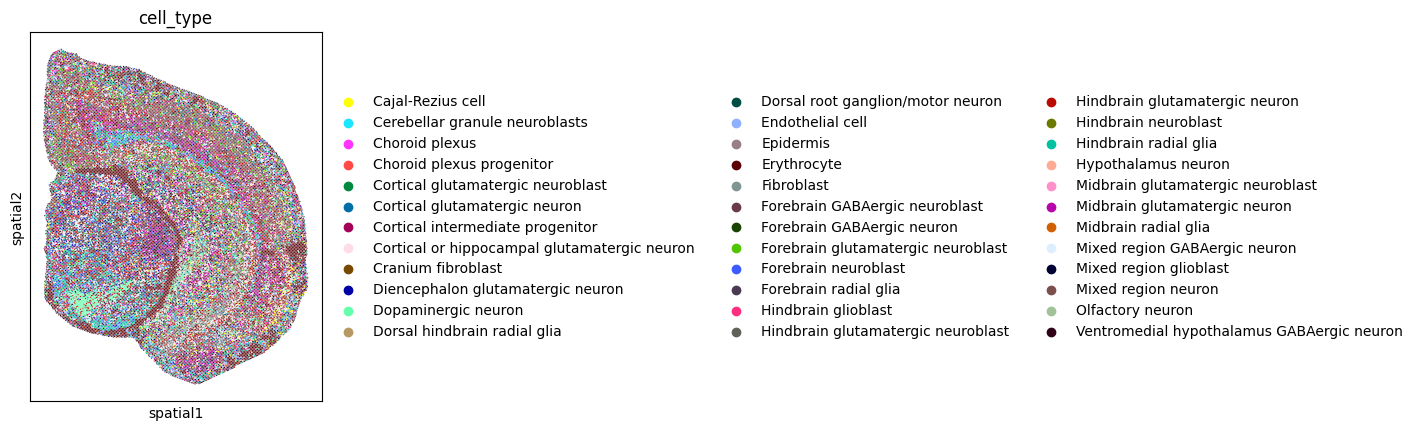

In [ ]:
sc.pl.spatial(adata, color="cell_type", spot_size=1)

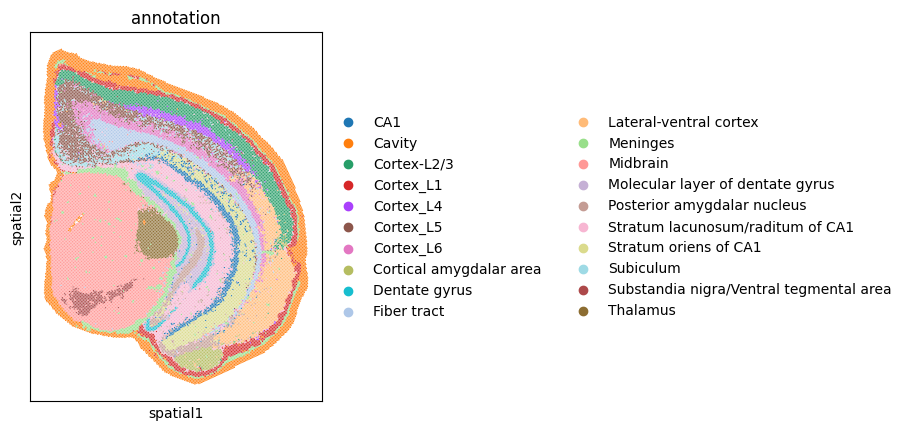

In [ ]:
sc.pl.spatial(adata, color="annotation", spot_size=1)

In [ ]:
sc.pp.normalize_total(adata, inplace=True)
sc.pp.log1p(adata)

In [ ]:
df_ligrec

,0,1,2,3
0,Tgfb1,Tgfbr1_Tgfbr2,TGFb,Secreted Signaling
1,Tgfb2,Tgfbr1_Tgfbr2,TGFb,Secreted Signaling
2,Tgfb3,Tgfbr1_Tgfbr2,TGFb,Secreted Signaling
3,Tgfb1,Acvr1b_Tgfbr2,TGFb,Secreted Signaling
4,Tgfb1,Acvr1c_Tgfbr2,TGFb,Secreted Signaling
...,...,...,...,...
1204,Uts2b,Uts2r,UROTENSIN,Secreted Signaling
1205,Uts2b,Sstr5,UROTENSIN,Secreted Signaling
1206,Bag6,Ncr3-ps,BAG,Secreted Signaling
1207,Lgals9,Havcr2,GALECTIN,Secreted Signaling


In [ ]:
df_cellchat_filtered = ct.pp.filter_lr_database(df_ligrec, adata, min_cell_pct=0.05)
print(df_cellchat_filtered.shape)

(29, 4)


In [ ]:
print(df_cellchat_filtered.head(10))

       0          1     2                   3
0  Wnt7b  Fzd3_Lrp6   WNT  Secreted Signaling
1   Nrg1      Erbb4   NRG  Secreted Signaling
2   Nrg3      Erbb4   NRG  Secreted Signaling
3   Fgf1      Fgfr1   FGF  Secreted Signaling
4   Fgf1      Fgfr2   FGF  Secreted Signaling
5   Fgf1      Fgfr3   FGF  Secreted Signaling
6   Fgf9      Fgfr1   FGF  Secreted Signaling
7   Fgf9      Fgfr2   FGF  Secreted Signaling
8   Fgf9      Fgfr3   FGF  Secreted Signaling
9  Vegfb       Flt1  VEGF  Secreted Signaling


In [2]:
adata_result = sc.read_h5ad("/home/akram/share/Result/COMMOT_Sequence/adata_spatial_communication.h5ad")

In [4]:
print(adata_result)

AnnData object with n_obs × n_vars = 38746 × 26177
    obs: 'annotation', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'score_Forebrain radial glia', 'score_Forebrain neuroblast', 'score_Forebrain glutamatergic neuroblast', 'score_Forebrain GABAergic neuroblast', 'score_Forebrain GABAergic neuron', 'score_Cajal-Rezius cell', 'score_Cortical glutamatergic neuroblast', 'score_Cortical or hippocampal glutamatergic neuron', 'score_Cortical intermediate progenitor', 'score_Cortical glutamatergic neuron', 'score_Olfactory neuron', 'score_Hypothalamus neuron', 'score_Ventromedial hypothalamus GABAergic neuron', 'score_Diencephalon glutamatergic neuron', 'score_Midbrain radial glia', 'score_Midbrain glutamatergic neuroblast', 'score_Midbrain glutamatergic neuron', 'score_Dopaminergic neuron', 'score_Hindbrain radial glia', 'score_Hi

In [5]:
adata_result.obsp.keys()


KeysView(PairwiseArrays with keys: commot-cellchat-Bdnf-Ntrk2, commot-cellchat-CCK, commot-cellchat-CSF, commot-cellchat-Cck-Cckbr, commot-cellchat-FGF, commot-cellchat-Fgf1-Fgfr1, commot-cellchat-Fgf1-Fgfr2, commot-cellchat-Fgf1-Fgfr3, commot-cellchat-Fgf9-Fgfr1, commot-cellchat-Fgf9-Fgfr2, commot-cellchat-Fgf9-Fgfr3, commot-cellchat-GAS, commot-cellchat-GRN, commot-cellchat-Gas6-Mertk, commot-cellchat-Gas6-Tyro3, commot-cellchat-Grn-Sort1, commot-cellchat-IGF, commot-cellchat-Igf2-Igf1r, commot-cellchat-Il34-Csf1r, commot-cellchat-KIT, commot-cellchat-Kitl-Kit, commot-cellchat-NPY, commot-cellchat-NRG, commot-cellchat-NT, commot-cellchat-Nampt-Insr, commot-cellchat-Npy-Npy1r, commot-cellchat-Nrg1-Erbb4, commot-cellchat-Nrg3-Erbb4, commot-cellchat-OPIOID, commot-cellchat-PROS, commot-cellchat-PSAP, commot-cellchat-PTN, commot-cellchat-Penk-Oprl1, commot-cellchat-Pros1-Tyro3, commot-cellchat-Psap-Gpr37, commot-cellchat-Psap-Gpr37l1, commot-cellchat-Ptn-Ncl, commot-cellchat-Ptn-Ptprz1, 

In [3]:
sender_labels = adata_result.obs['cell_type']
receiver_labels = adata_result.obs['cell_type']

In [6]:
lr_names = [key for key in adata_result.obsp.keys() if key.startswith('commot-cellchat')]

all_summaries = []

for lr_name in lr_names:
    lr_matrix = adata_result.obsp[lr_name]
    lr_df = pd.DataFrame(lr_matrix.toarray(), index=sender_labels, columns=receiver_labels)
    summary = lr_df.groupby(level=0).sum().groupby(axis=1, level=0).sum()
    
    # Add a column or index to identify the LR pair
    summary['LR_pair'] = lr_name.replace('commot-cellchat-', '').replace('-', '_')
    
    # Convert to long format for easier concatenation
    summary_long = summary.reset_index().melt(id_vars=['cell_type', 'LR_pair'], var_name='receiver_cell_type', value_name='interaction_strength')
    
    all_summaries.append(summary_long)

# Concatenate all results
final_df = pd.concat(all_summaries, ignore_index=True)

# Save to one CSV
final_df.to_csv('all_lr_interactions_summary.csv', index=False)

print("All ligand-receptor summaries saved to all_lr_interactions_summary.csv")


All ligand-receptor summaries saved to all_lr_interactions_summary.csv


In [7]:
final_df= pd.read_csv("/home/akram/share/Result/COMMOT_Sequence/all_lr_interactions_summary.csv")

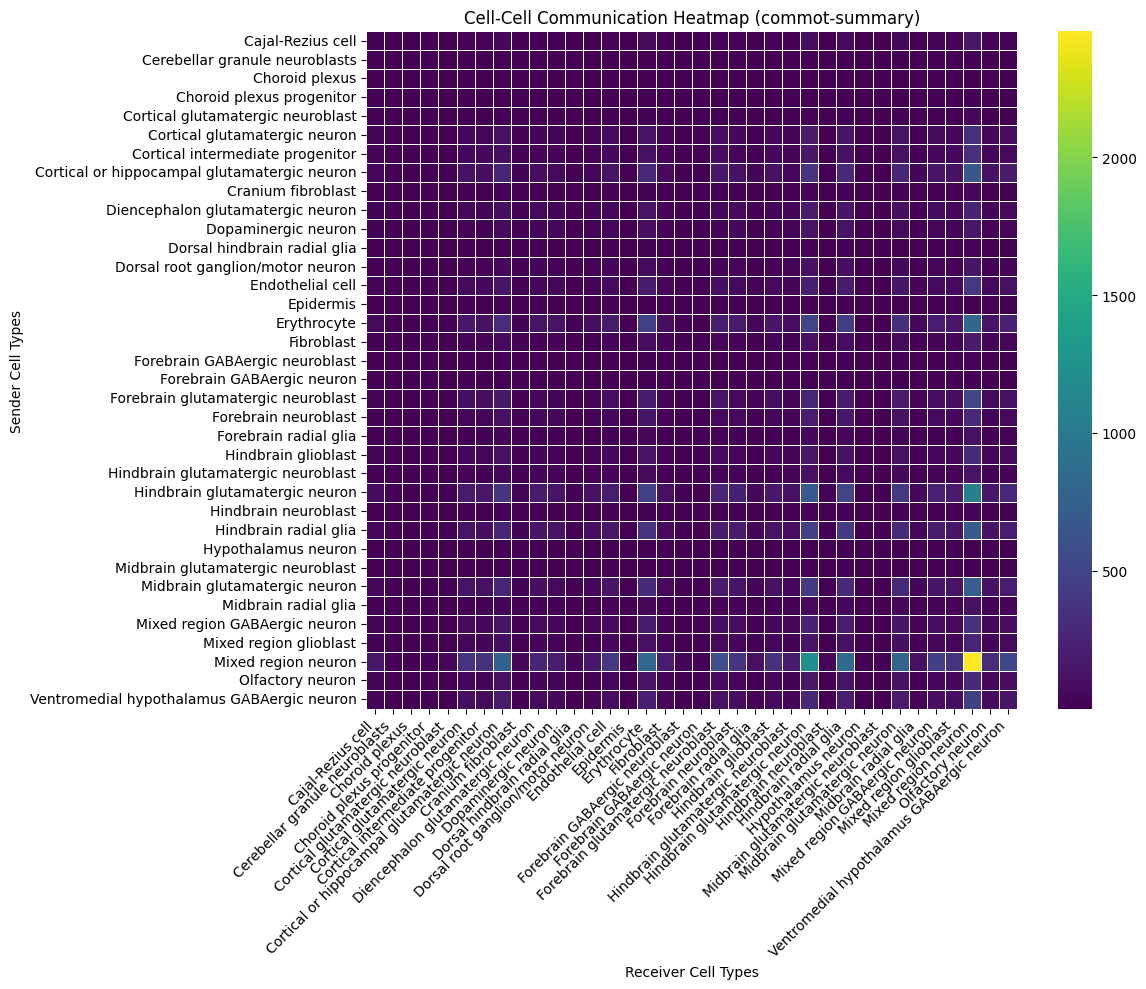

In [8]:
# Extract the total-total matrix
total_total_matrix = adata_result.obsp['commot-cellchat-total-total']

# Convert to DataFrame (make sure sender_labels and receiver_labels are defined)
total_total_df = pd.DataFrame(total_total_matrix.toarray(), index=sender_labels, columns=receiver_labels)

# Summarize by cell type (group by sender and receiver cell types)
summary = total_total_df.groupby(level=0).sum().groupby(axis=1, level=0).sum()

# Plot heatmap
plt.figure(figsize=(12,10))
sns.heatmap(summary, cmap='viridis', linewidths=0.5)
plt.title('Cell-Cell Communication Heatmap (commot-summary)')
plt.xlabel('Receiver Cell Types')
plt.ylabel('Sender Cell Types')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()



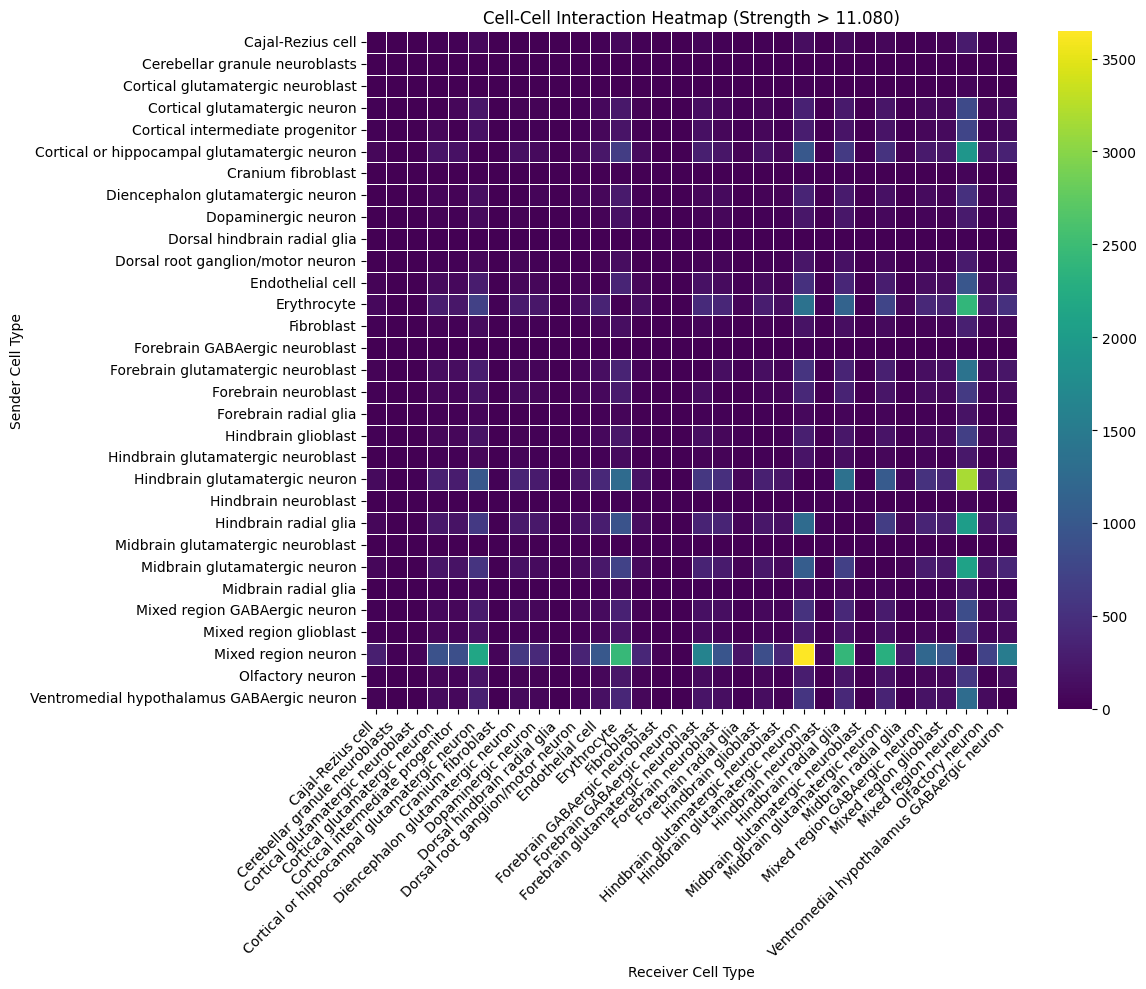

In [16]:
# Choose cutoff
cutoff = final_df['interaction_strength'].quantile(0.95)

# Filter data (exclude sender == receiver)
filtered_df = final_df[(final_df['interaction_strength'] > cutoff) & (final_df['cell_type'] != final_df['receiver_cell_type'])]

# Pivot table: sum interaction strengths for each sender-receiver pair
heatmap_data = filtered_df.pivot_table(
    index='cell_type',
    columns='receiver_cell_type',
    values='interaction_strength',
    aggfunc='sum',
    fill_value=0
)

# Plot heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(heatmap_data, cmap='viridis', linewidths=0.5)
plt.title(f'Cell-Cell Interaction Heatmap (Strength > {cutoff:.3f})')
plt.xlabel('Receiver Cell Type')
plt.ylabel('Sender Cell Type')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [18]:
# Filter out pathway-level results to get only specific L-R pairs
# Specific L-R pairs have the format "Ligand-Receptor" (with hyphen)
specific_lr_pairs = df_results[df_results.index.str.contains('-')]

# Remove pathway-level entries (all caps without hyphens)
pathway_names = ['PTN', 'PSAP', 'FGF', 'GAS', 'GRN', 'IGF', 'KIT', 'NPY', 'NRG', 
                 'NT', 'OPIOID', 'PROS', 'VEGF', 'VISFATIN', 'WNT', 'CCK', 'CSF']

# Filter to keep only specific ligand-receptor pairs
specific_lr_pairs = df_results[~df_results.index.isin(pathway_names)]

# Get top 5 specific ligand-receptor pairs
top_5_specific_lr = specific_lr_pairs.nlargest(5, 'total_communication')

print("TOP 5 SPECIFIC LIGAND-RECEPTOR PAIRS:")
print("=" * 45)
for i, (lr_pair, row) in enumerate(top_5_specific_lr.iterrows(), 1):
    print(f"{i}. {lr_pair}")
    print(f"   Total Communication: {row['total_communication']:.2e}")
    print()

print("CLEAN LIST:")
print("-" * 20)
for i, lr_pair in enumerate(top_5_specific_lr.index, 1):
    print(f"{i}. {lr_pair}")

TOP 5 SPECIFIC LIGAND-RECEPTOR PAIRS:
1. Ptn-Ncl
   Total Communication: 9.83e+03

2. Psap-Gpr37l1
   Total Communication: 7.95e+03

3. Ptn-Ptprz1
   Total Communication: 4.49e+03

4. Ptn-Sdc3
   Total Communication: 3.03e+03

5. Nrg3-Erbb4
   Total Communication: 2.83e+03

CLEAN LIST:
--------------------
1. Ptn-Ncl
2. Psap-Gpr37l1
3. Ptn-Ptprz1
4. Ptn-Sdc3
5. Nrg3-Erbb4


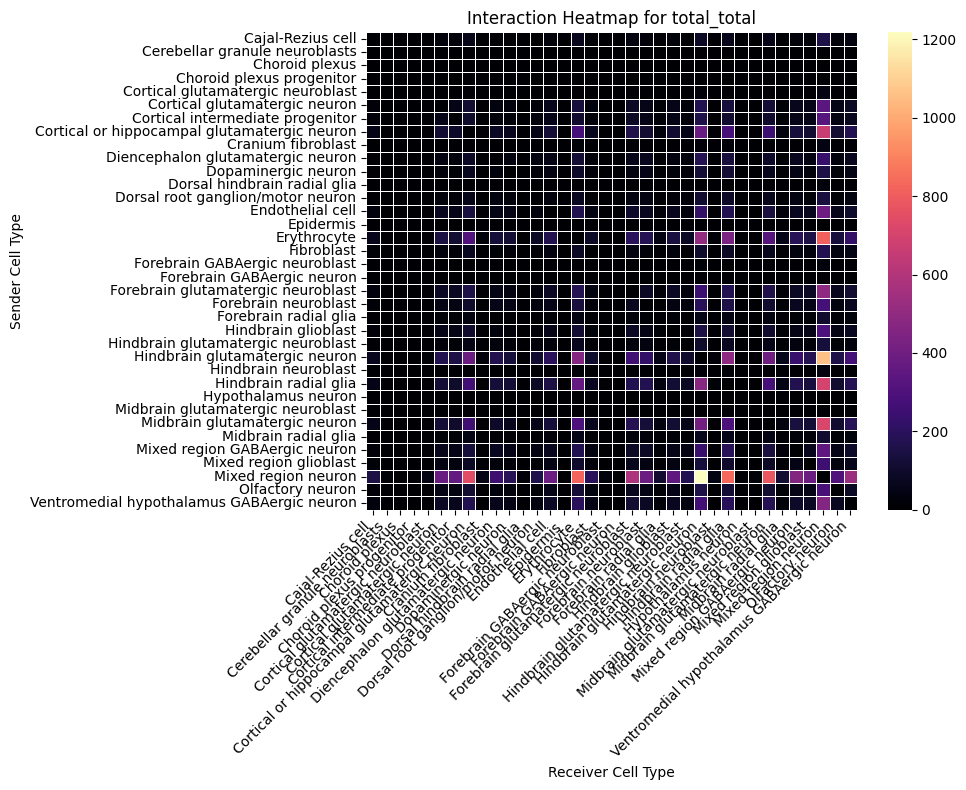

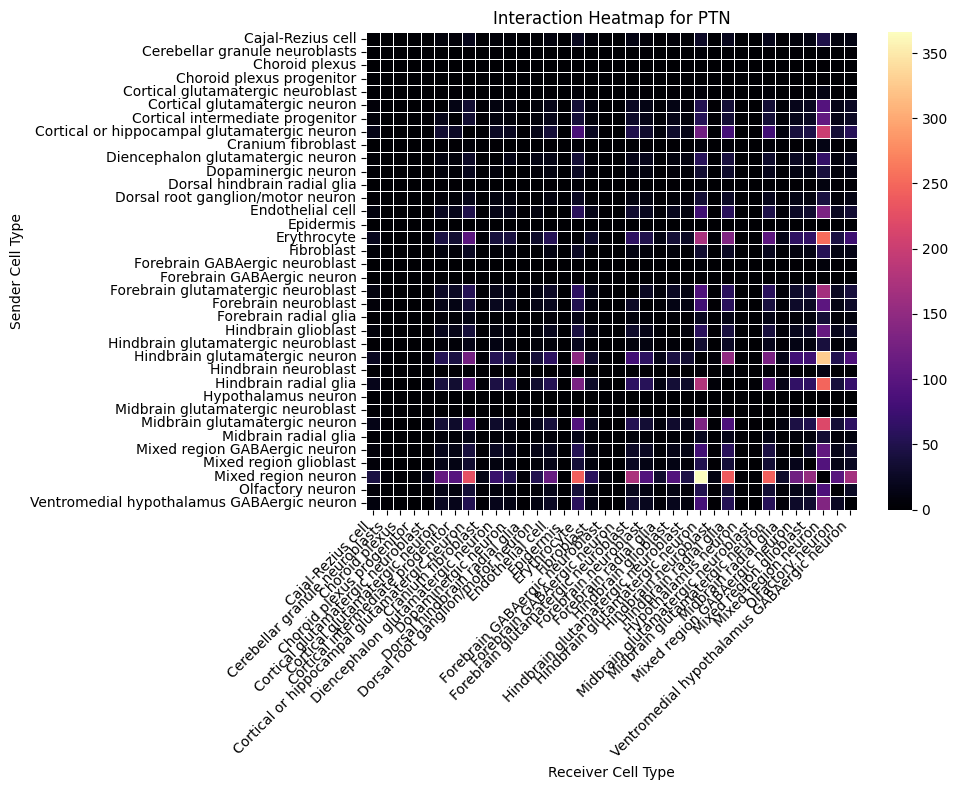

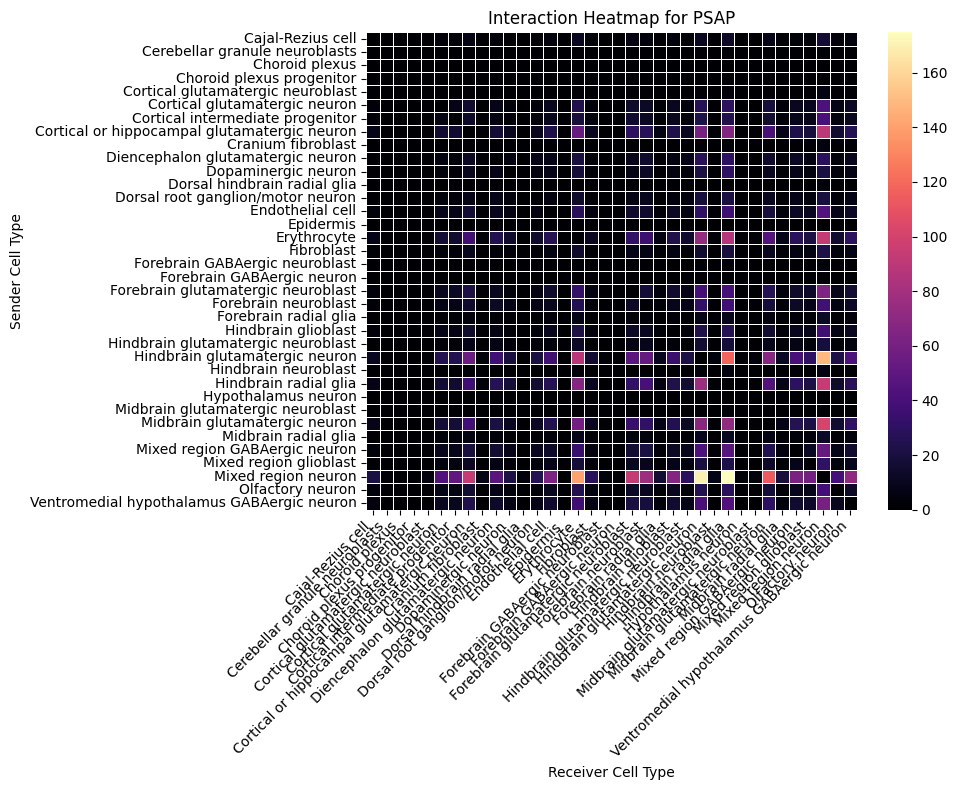

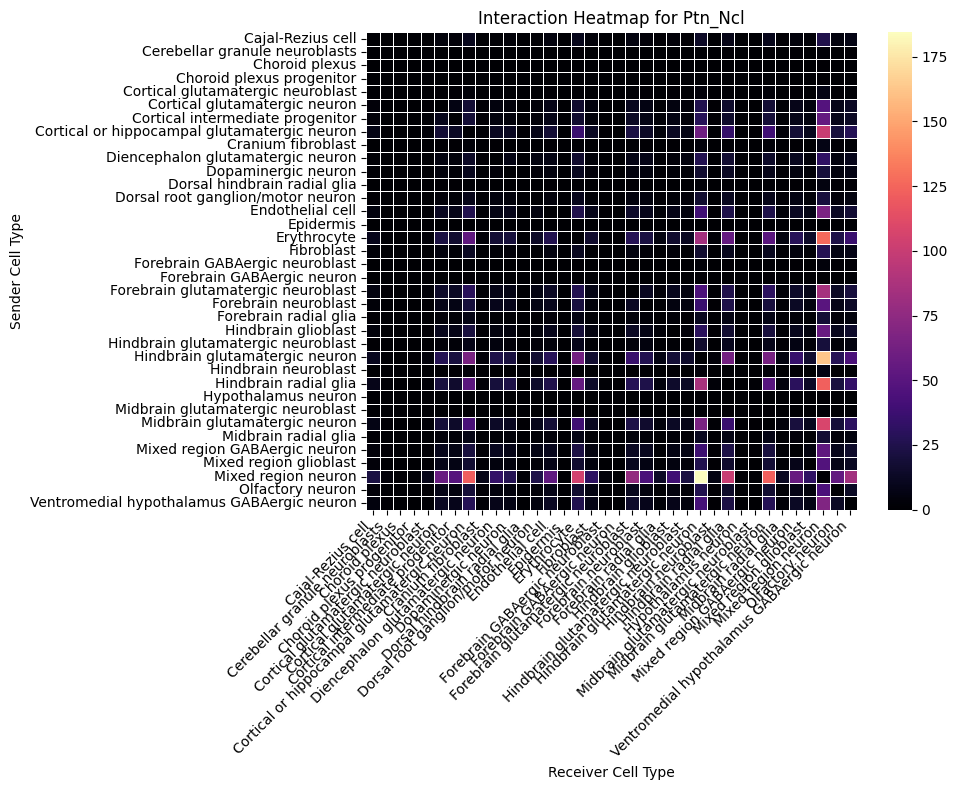

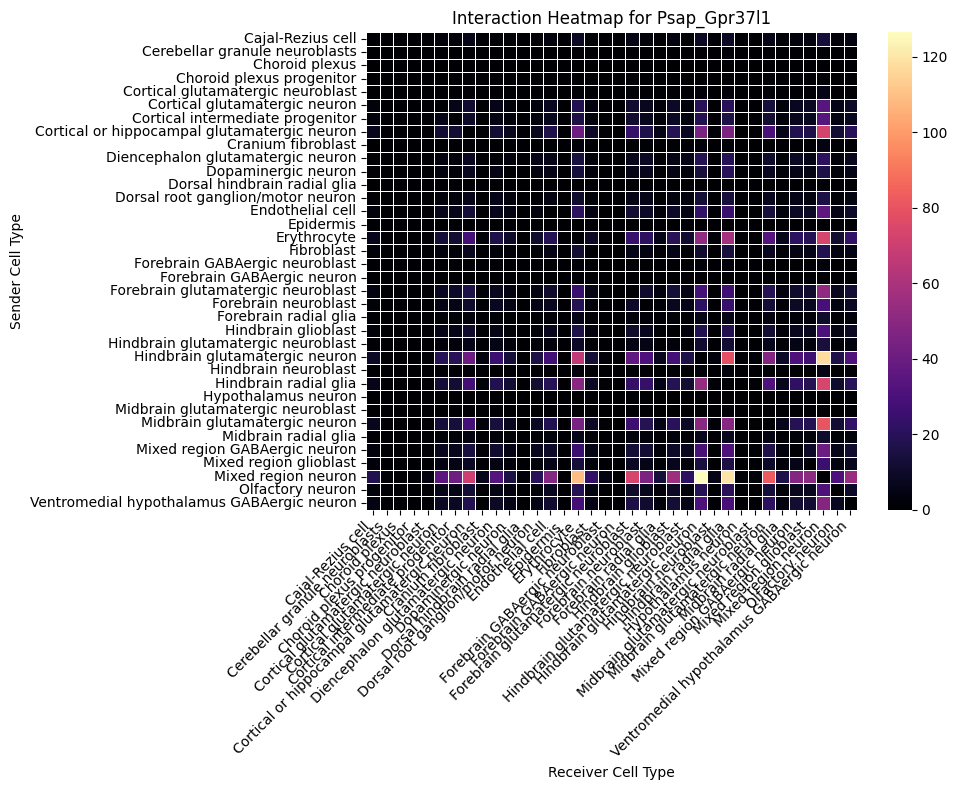

In [33]:
top_LRs = final_df.groupby("LR_pair")["interaction_strength"].sum().nlargest(5).index

for lr in top_LRs:
    df_lr = final_df[
        (final_df["LR_pair"] == lr) &
        (final_df["cell_type"] != final_df["receiver_cell_type"])
    ]

    heatmap_data = df_lr.pivot_table(
        index="cell_type",
        columns="receiver_cell_type",
        values="interaction_strength",
        aggfunc="sum",
        fill_value=0
    )

    plt.figure(figsize=(10, 8))
    sns.heatmap(heatmap_data, cmap="magma", linewidths=0.5)
    plt.title(f"Interaction Heatmap for {lr}")
    plt.xlabel("Receiver Cell Type")
    plt.ylabel("Sender Cell Type")
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()


In [8]:
adata_result

AnnData object with n_obs × n_vars = 38746 × 26177
    obs: 'annotation', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'score_Forebrain radial glia', 'score_Forebrain neuroblast', 'score_Forebrain glutamatergic neuroblast', 'score_Forebrain GABAergic neuroblast', 'score_Forebrain GABAergic neuron', 'score_Cajal-Rezius cell', 'score_Cortical glutamatergic neuroblast', 'score_Cortical or hippocampal glutamatergic neuron', 'score_Cortical intermediate progenitor', 'score_Cortical glutamatergic neuron', 'score_Olfactory neuron', 'score_Hypothalamus neuron', 'score_Ventromedial hypothalamus GABAergic neuron', 'score_Diencephalon glutamatergic neuron', 'score_Midbrain radial glia', 'score_Midbrain glutamatergic neuroblast', 'score_Midbrain glutamatergic neuron', 'score_Dopaminergic neuron', 'score_Hindbrain radial glia', 'score_Hi

### Save overall cell-type communication strength

In [9]:
total_total_matrix = adata_result.obsp['commot-cellchat-total-total']
total_total_df = pd.DataFrame(
    total_total_matrix.toarray(),
    index=sender_labels,
    columns=receiver_labels
)

commot_mat = total_total_df.groupby(level=0).sum().groupby(axis=1, level=0).sum()

commot_mat.to_csv("/home/akram/share/Result/COMMOT_Sequence/COMMOT_celltype_matrix.csv")
print("Saved: COMMOT_celltype_matrix.csv")
print(commot_mat.head())

Saved: COMMOT_celltype_matrix.csv
cell_type                          Cajal-Rezius cell  \
cell_type                                              
Cajal-Rezius cell                          12.504667   
Cerebellar granule neuroblasts              0.924674   
Choroid plexus                              0.330611   
Choroid plexus progenitor                   0.640647   
Cortical glutamatergic neuroblast           2.377536   

cell_type                          Cerebellar granule neuroblasts  \
cell_type                                                           
Cajal-Rezius cell                                        1.319233   
Cerebellar granule neuroblasts                           0.277497   
Choroid plexus                                           0.025345   
Choroid plexus progenitor                                0.054389   
Cortical glutamatergic neuroblast                        0.261897   

cell_type                          Choroid plexus  Choroid plexus progenitor  \
cell_type